# Delta CISI Projections

Projects future CISI by anchoring to the observed 2024 CISI baseline.

**Method:**
1. Run model on 2024 inputs → baseline prediction
2. Run model on each SSP scenario → future prediction
3. Compute delta = future − baseline per pixel
4. Apply delta to actual 2024 CISI: `projected = actual_CISI_2024 + delta`

This cancels the model's absolute underprediction bias and uses it purely as a change detector.

## 1. Imports and setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


## 2. Model definition

In [2]:
class CNN(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(config["dropout"]), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(config["dropout"]), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(config["dropout"]), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.Dropout(config["dropout"]),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(config["dropout"]),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)


## 3. Paths

In [3]:
MODEL_PATH  = "best_search_model.pt"
CISI_PATH   = r"READY_data\labels\2024_CISI_010deg_nearest.tif"
SHP_PATH    = r"ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp"
OUTPUT_DIR  = "predictions"
NORM_DIR    = r"READY_data\inputs_normalized\ssp"
PATCH_SIZE  = 16
HALF        = PATCH_SIZE // 2
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2024 baseline inputs
BASELINE = {
    "gdp": r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif",
    "pop": r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif",
    "lc":  r"READY_data\landuse_onehot\clipped_history_2020_onehot.tif",
}

# SSP future inputs
SCENARIOS = {
    "SSP1": {
        2030: {"gdp": rf"{NORM_DIR}\GDP_SSP1_2030_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP1_2030_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP1_2030_class_{c}.tif" for c in range(1,8)]},
        2050: {"gdp": rf"{NORM_DIR}\GDP_SSP1_2050_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP1_2050_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP1_2050_class_{c}.tif" for c in range(1,8)]},
        2100: {"gdp": rf"{NORM_DIR}\GDP_SSP1_2100_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP1_2100_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP1_2100_class_{c}.tif" for c in range(1,8)]},
    },
    "SSP2": {
        2030: {"gdp": rf"{NORM_DIR}\GDP_SSP2_2030_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP2_2030_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP2_2030_class_{c}.tif" for c in range(1,8)]},
        2050: {"gdp": rf"{NORM_DIR}\GDP_SSP2_2050_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP2_2050_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP2_2050_class_{c}.tif" for c in range(1,8)]},
        2100: {"gdp": rf"{NORM_DIR}\GDP_SSP2_2100_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP2_2100_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP2_2100_class_{c}.tif" for c in range(1,8)]},
    },
    "SSP3": {
        2030: {"gdp": rf"{NORM_DIR}\GDP_SSP3_2030_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP3_2030_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP3_2030_class_{c}.tif" for c in range(1,8)]},
        2050: {"gdp": rf"{NORM_DIR}\GDP_SSP3_2050_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP3_2050_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP3_2050_class_{c}.tif" for c in range(1,8)]},
        2100: {"gdp": rf"{NORM_DIR}\GDP_SSP3_2100_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP3_2100_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP3_2100_class_{c}.tif" for c in range(1,8)]},
    },
    "SSP4": {
        2030: {"gdp": rf"{NORM_DIR}\GDP_SSP4_2030_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP4_2030_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP4_2030_class_{c}.tif" for c in range(1,8)]},
        2050: {"gdp": rf"{NORM_DIR}\GDP_SSP4_2050_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP4_2050_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP4_2050_class_{c}.tif" for c in range(1,8)]},
        2100: {"gdp": rf"{NORM_DIR}\GDP_SSP4_2100_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP4_2100_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP4_2100_class_{c}.tif" for c in range(1,8)]},
    },
    "SSP5": {
        2030: {"gdp": rf"{NORM_DIR}\GDP_SSP5_2030_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP5_2030_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP5_2030_class_{c}.tif" for c in range(1,8)]},
        2050: {"gdp": rf"{NORM_DIR}\GDP_SSP5_2050_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP5_2050_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP5_2050_class_{c}.tif" for c in range(1,8)]},
        2100: {"gdp": rf"{NORM_DIR}\GDP_SSP5_2100_normalized.tif", "pop": rf"{NORM_DIR}\POP_SSP5_2100_normalized.tif", "lc": [rf"{NORM_DIR}\LC_SSP5_2100_class_{c}.tif" for c in range(1,8)]},
    },
}


## 4. Load model and reference data

In [4]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
config = checkpoint.get("params", checkpoint.get("config", {"dropout": 0.2}))
model = CNN({"dropout": config["dropout"]}).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Model loaded. Config: {config}")

with rasterio.open(CISI_PATH) as src:
    cisi_2024  = src.read(1).astype(np.float32)
    REF_SHAPE  = (src.height, src.width)
    REF_BOUNDS = src.bounds
    VALID_MASK = ~np.isnan(cisi_2024)

print(f"Reference grid: {REF_SHAPE}, valid pixels: {VALID_MASK.sum():,}")


Model loaded. Config: {'lam': 30, 'lr': 0.00021583385016821986, 'dropout': 0.2}
Reference grid: (485, 570), valid pixels: 87,346


## 5. Helper functions

In [5]:
def build_stack(gdp_path, pop_path, lc_paths):
    """Load and stack inputs into (9, H, W), NaN -> 0."""
    with rasterio.open(gdp_path) as src: gdp = src.read(1).astype(np.float32)
    with rasterio.open(pop_path) as src: pop = src.read(1).astype(np.float32)
    lc = np.concatenate([rasterio.open(p).read().astype(np.float32) for p in lc_paths], axis=0)
    stack = np.concatenate([gdp[np.newaxis], pop[np.newaxis], lc], axis=0)
    return np.nan_to_num(stack, nan=0.0)


def predict_raster(input_stack):
    """Run model on all valid pixels, return (H, W) prediction map."""
    H, W = REF_SHAPE
    pred_map = np.full((H, W), np.nan, dtype=np.float32)
    valid_idx = np.argwhere(VALID_MASK)
    patches, coords = [], []

    for i, j in valid_idx:
        pad_top    = max(0, HALF - i)
        pad_bottom = max(0, (i + HALF) - H)
        pad_left   = max(0, HALF - j)
        pad_right  = max(0, (j + HALF) - W)
        i0 = max(0, i - HALF); i1 = min(H, i + HALF)
        j0 = max(0, j - HALF); j1 = min(W, j + HALF)
        patch = input_stack[:, i0:i1, j0:j1].copy()
        if pad_top or pad_bottom or pad_left or pad_right:
            patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode="edge")
        patches.append(patch)
        coords.append((i, j))

        if len(patches) == 512:
            batch = torch.FloatTensor(np.stack(patches)).to(device)
            with torch.no_grad():
                out = model(batch).cpu().numpy().flatten()
            for (pi, pj), p in zip(coords, out):
                pred_map[pi, pj] = p
            patches, coords = [], []

    if patches:
        batch = torch.FloatTensor(np.stack(patches)).to(device)
        with torch.no_grad():
            out = model(batch).cpu().numpy().flatten()
        for (pi, pj), p in zip(coords, out):
            pred_map[pi, pj] = p

    return pred_map


## 6. Compute baseline prediction (2024 inputs)

In [6]:
print("Running baseline (2024 inputs)...")
baseline_stack = build_stack(
    BASELINE["gdp"], BASELINE["pop"],
    [BASELINE["lc"]] if isinstance(BASELINE["lc"], str) else BASELINE["lc"]
)

# LC in baseline is multiband — split into 7 single-band arrays for build_stack
with rasterio.open(BASELINE["gdp"]) as src: gdp_b = src.read(1).astype(np.float32)
with rasterio.open(BASELINE["pop"]) as src: pop_b = src.read(1).astype(np.float32)
with rasterio.open(BASELINE["lc"])  as src: lc_b  = src.read().astype(np.float32)
baseline_stack = np.nan_to_num(np.concatenate([gdp_b[np.newaxis], pop_b[np.newaxis], lc_b], axis=0), nan=0.0)

pred_baseline = predict_raster(baseline_stack)
print(f"Baseline done. mean={np.nanmean(pred_baseline):.4f}  max={np.nanmax(pred_baseline):.4f}")


Running baseline (2024 inputs)...
Baseline done. mean=0.0474  max=0.4234


## 7. Run delta projections for all SSP scenarios

In [7]:
results_delta    = {}  # delta = pred_future - pred_baseline
results_projected = {}  # projected = actual_cisi_2024 + delta

for ssp, years in SCENARIOS.items():
    results_delta[ssp]     = {}
    results_projected[ssp] = {}
    for year, paths in years.items():
        missing = [p for p in [paths["gdp"], paths["pop"]] + paths["lc"] if not os.path.exists(p)]
        if missing:
            print(f"SKIPPING {ssp} {year} — missing: {[os.path.basename(m) for m in missing]}")
            continue

        print(f"Running {ssp} {year}...")
        stack = build_stack(paths["gdp"], paths["pop"], paths["lc"])
        pred_future = predict_raster(stack)

        delta     = pred_future - pred_baseline
        projected = np.clip(cisi_2024 + delta, 0, 1)
        projected[~VALID_MASK] = np.nan

        results_delta[ssp][year]     = delta
        results_projected[ssp][year] = projected

        # Save GeoTIFFs
        with rasterio.open(CISI_PATH) as ref:
            profile = ref.profile.copy()
        profile.update(dtype="float32", count=1, nodata=np.nan)

        out_delta = f"{OUTPUT_DIR}/delta_{ssp}_{year}.tif"
        with rasterio.open(out_delta, "w", **profile) as dst:
            dst.write(delta[np.newaxis, :, :])

        out_proj = f"{OUTPUT_DIR}/projected_cisi_{ssp}_{year}.tif"
        with rasterio.open(out_proj, "w", **profile) as dst:
            dst.write(projected[np.newaxis, :, :])

        print(f"  delta mean={np.nanmean(delta):+.4f}  projected mean={np.nanmean(projected):.4f}  max={np.nanmax(projected):.4f}")

print("Done.")


Running SSP1 2030...
  delta mean=-0.0068  projected mean=0.0232  max=0.5518
Running SSP1 2050...
  delta mean=-0.0066  projected mean=0.0233  max=0.5489
Running SSP1 2100...
  delta mean=-0.0066  projected mean=0.0234  max=0.5489
Running SSP2 2030...
  delta mean=-0.0071  projected mean=0.0229  max=0.5593
Running SSP2 2050...
  delta mean=-0.0069  projected mean=0.0231  max=0.5535
Running SSP2 2100...
  delta mean=-0.0066  projected mean=0.0233  max=0.5547
Running SSP3 2030...
  delta mean=-0.0071  projected mean=0.0229  max=0.5682
Running SSP3 2050...
  delta mean=-0.0069  projected mean=0.0231  max=0.5563
Running SSP3 2100...
  delta mean=-0.0067  projected mean=0.0232  max=0.5627
Running SSP4 2030...
  delta mean=-0.0070  projected mean=0.0230  max=0.5647
Running SSP4 2050...
  delta mean=-0.0068  projected mean=0.0232  max=0.5526
Running SSP4 2100...
  delta mean=-0.0067  projected mean=0.0233  max=0.5527
Running SSP5 2030...
  delta mean=-0.0070  projected mean=0.0230  max=0.5632

## 8. Maps — projected CISI per year (all SSPs)

Saved delta_projections_2030.png


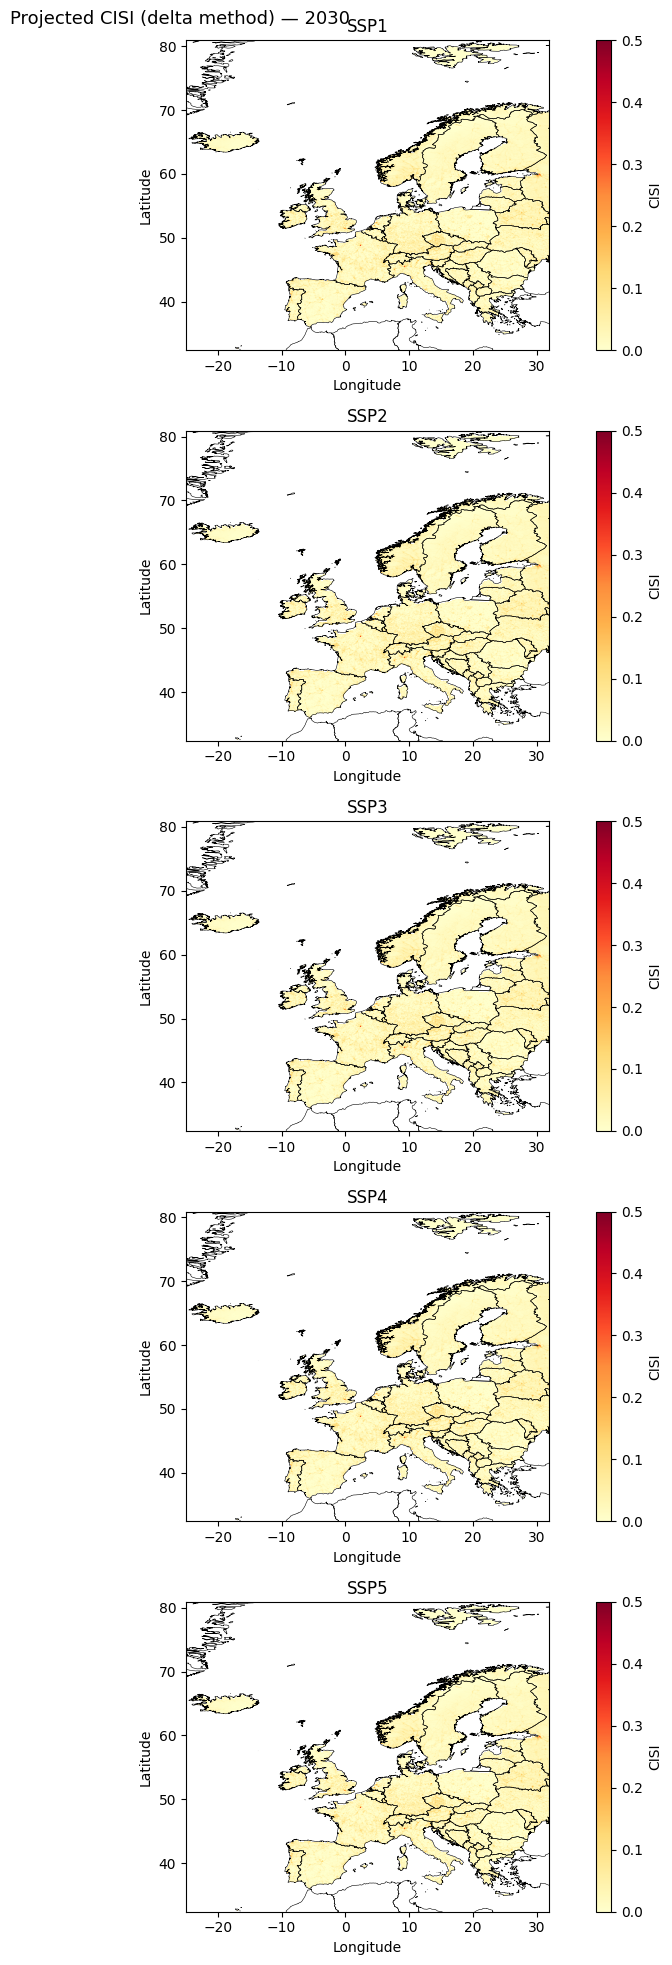

Saved delta_projections_2050.png


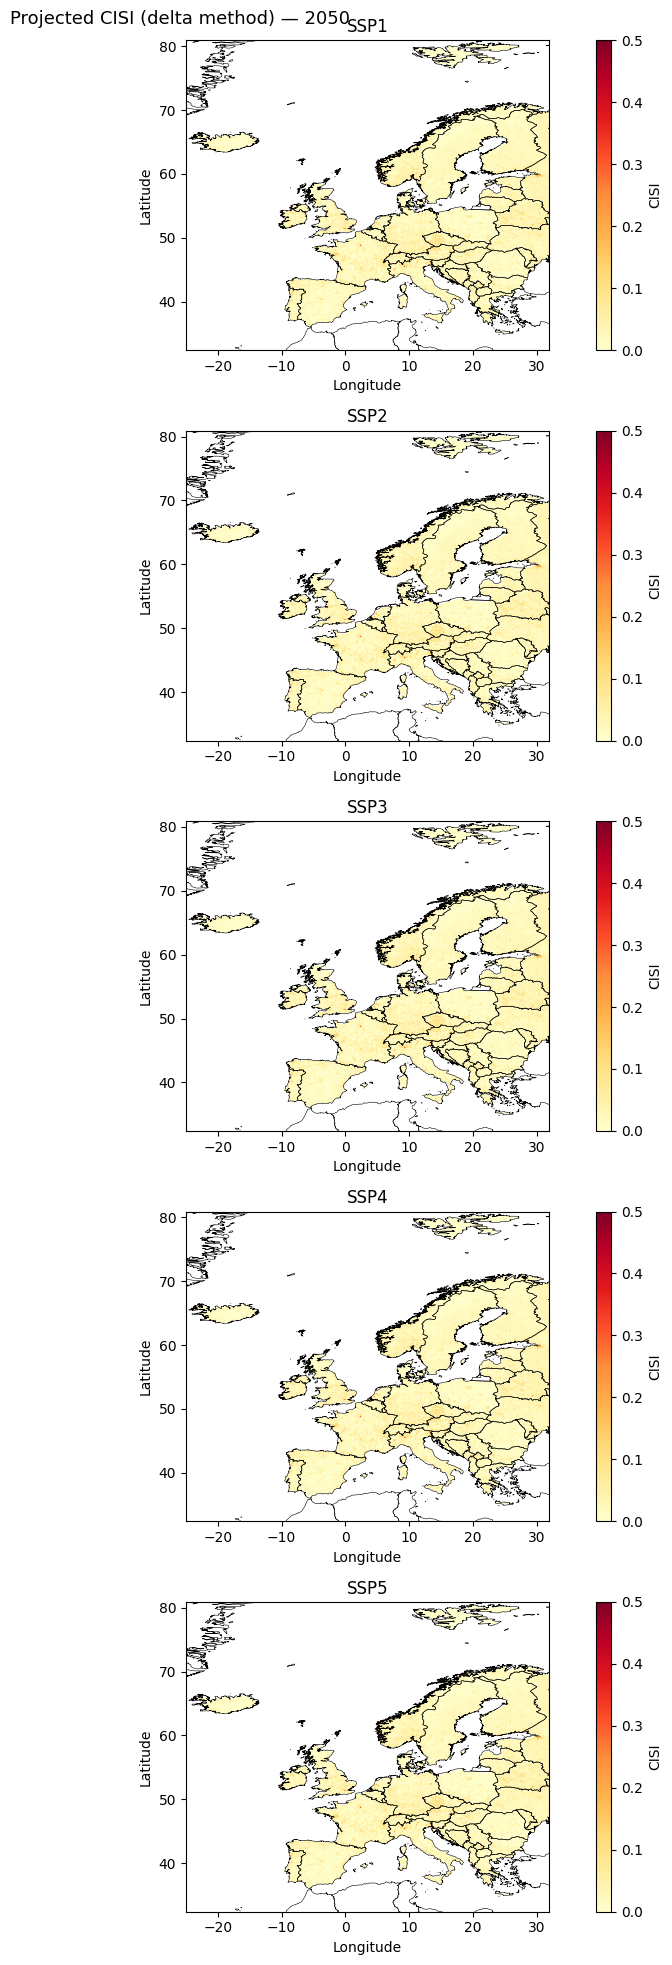

Saved delta_projections_2100.png


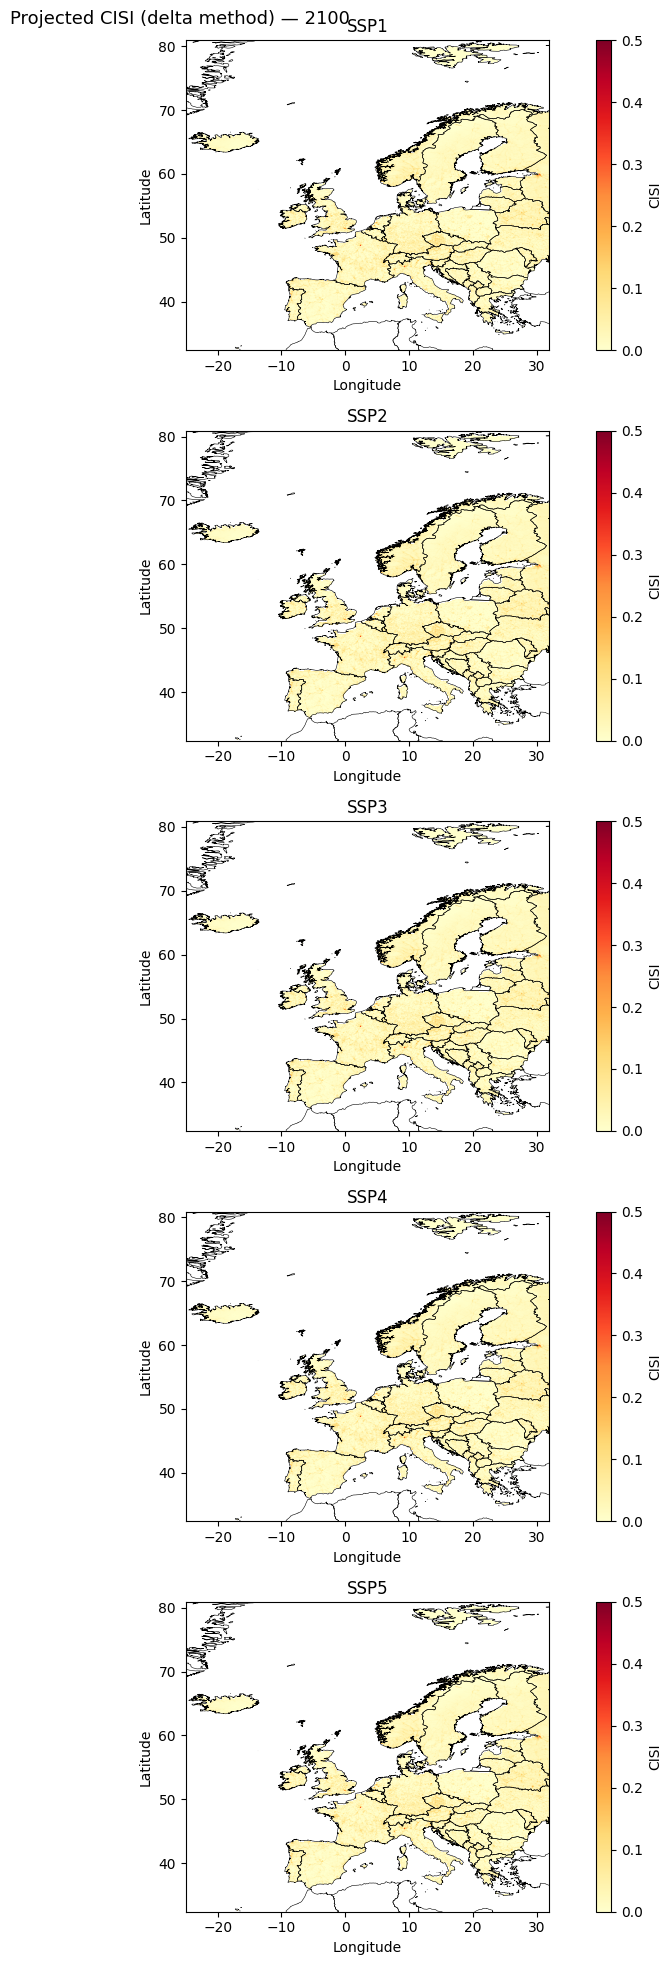

In [8]:
world = gpd.read_file(SHP_PATH)
SSPS  = list(SCENARIOS.keys())
YEARS = [2030, 2050, 2100]
ext   = [REF_BOUNDS.left, REF_BOUNDS.right, REF_BOUNDS.bottom, REF_BOUNDS.top]

for year in YEARS:
    ssps_ok = [s for s in SSPS if year in results_projected.get(s, {})]
    if not ssps_ok:
        continue

    fig, axes = plt.subplots(len(ssps_ok), 1, figsize=(10, 4 * len(ssps_ok)))
    if len(ssps_ok) == 1:
        axes = [axes]
    fig.suptitle(f"Projected CISI (delta method) — {year}", fontsize=13)

    for ax, ssp in zip(axes, ssps_ok):
        proj = results_projected[ssp][year]
        im = ax.imshow(proj, cmap="YlOrRd", vmin=0, vmax=0.5,
                       extent=ext, origin="upper", aspect="auto")
        world.boundary.plot(ax=ax, linewidth=0.4, color="black")
        ax.set_xlim(REF_BOUNDS.left, REF_BOUNDS.right)
        ax.set_ylim(REF_BOUNDS.bottom, REF_BOUNDS.top)
        plt.colorbar(im, ax=ax, label="CISI", fraction=0.03)
        ax.set_title(ssp)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    plt.tight_layout()
    out_fig = f"delta_projections_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches="tight")
    print(f"Saved {out_fig}")
    plt.show()


## 9. Delta maps — change relative to 2024 baseline

Saved delta_change_2030.png


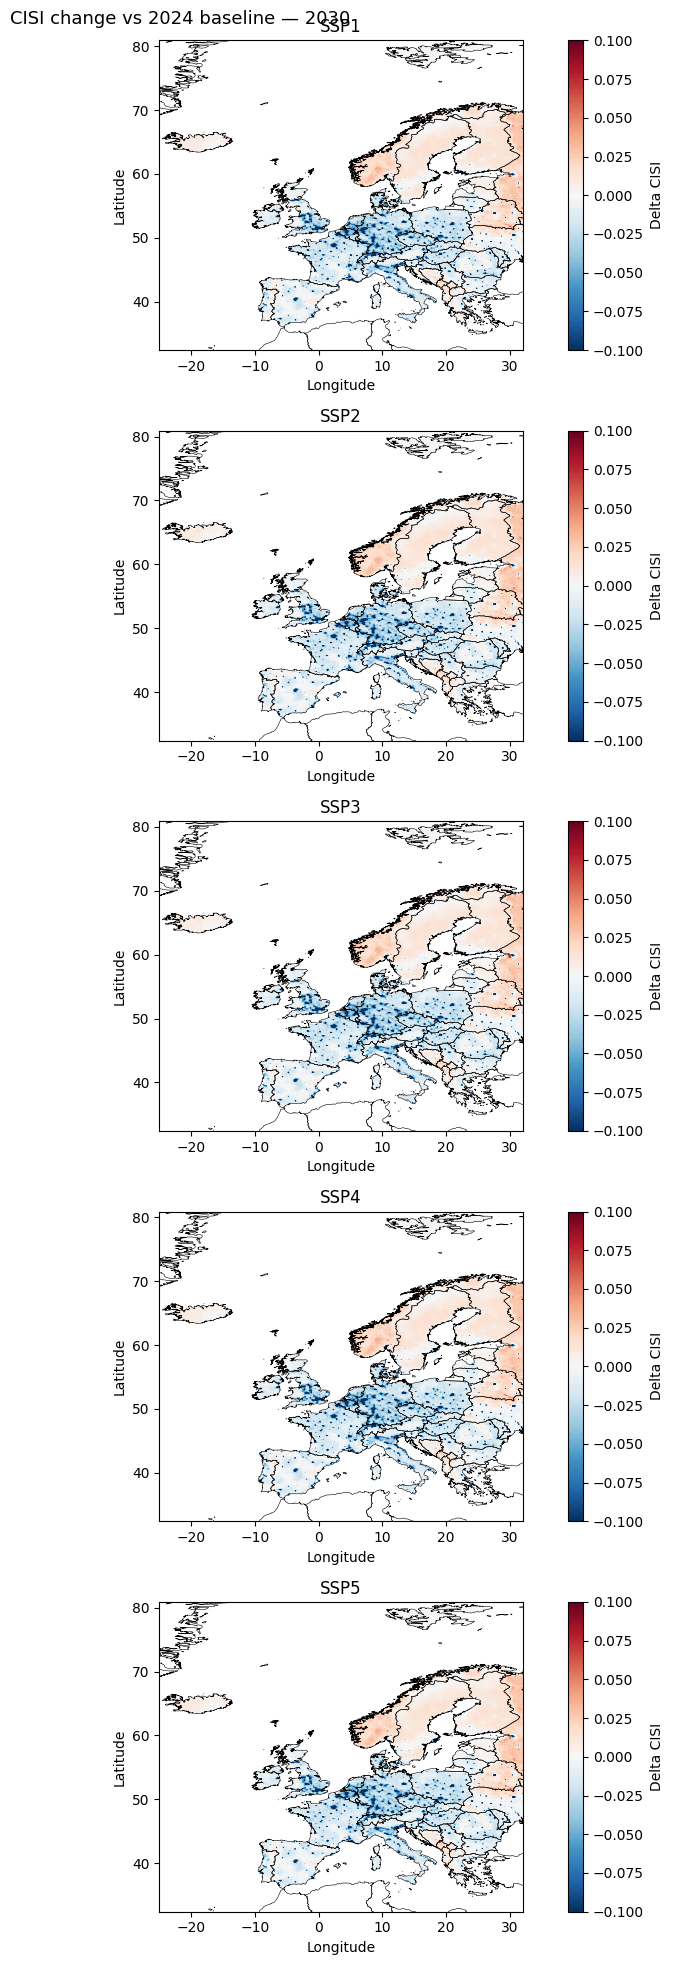

Saved delta_change_2050.png


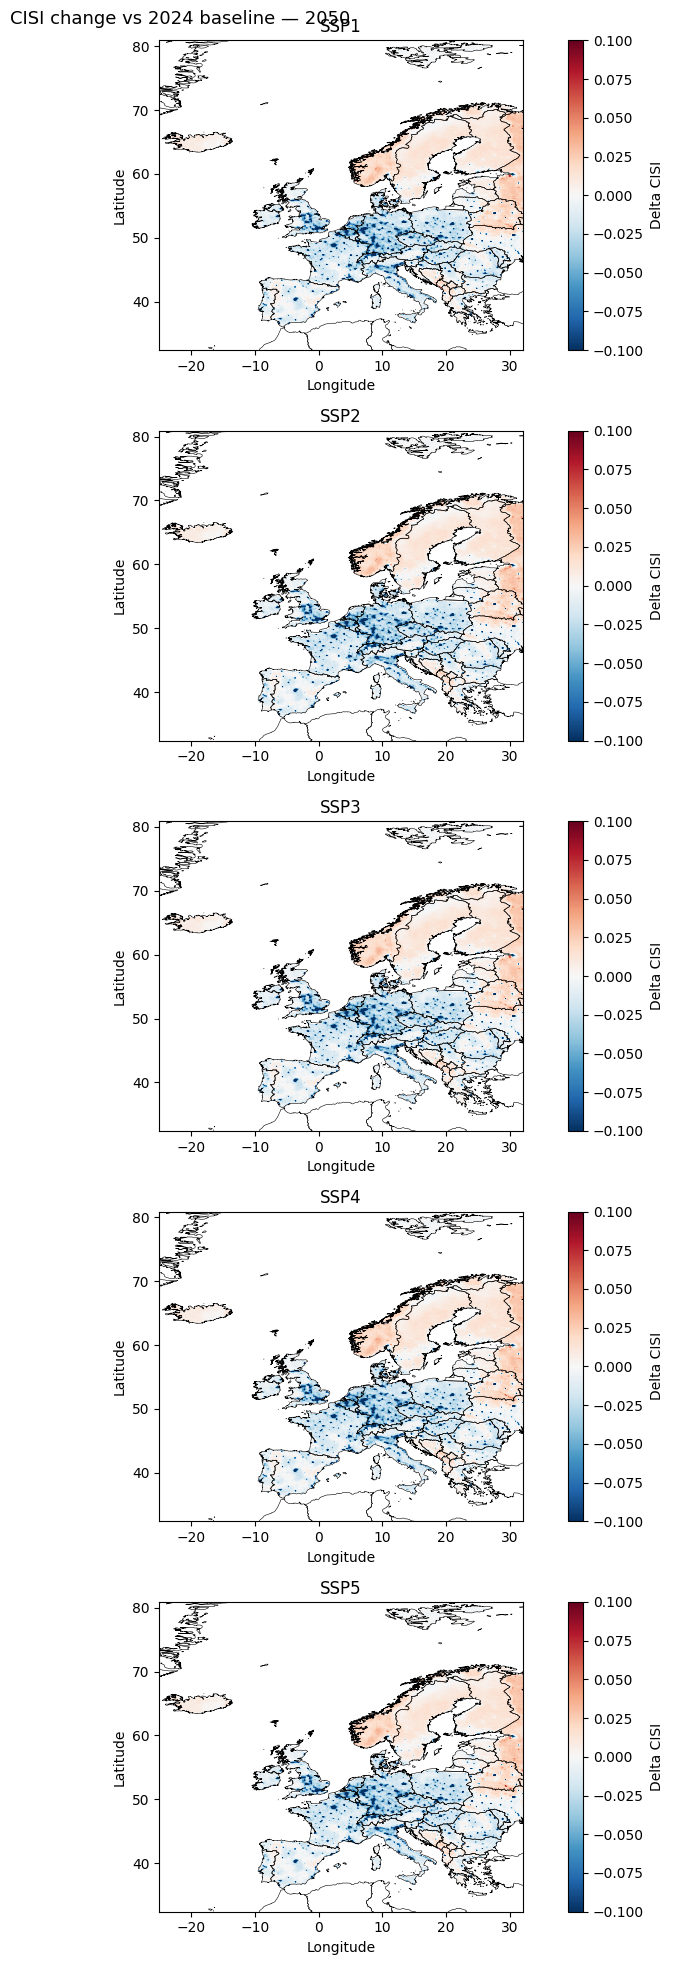

Saved delta_change_2100.png


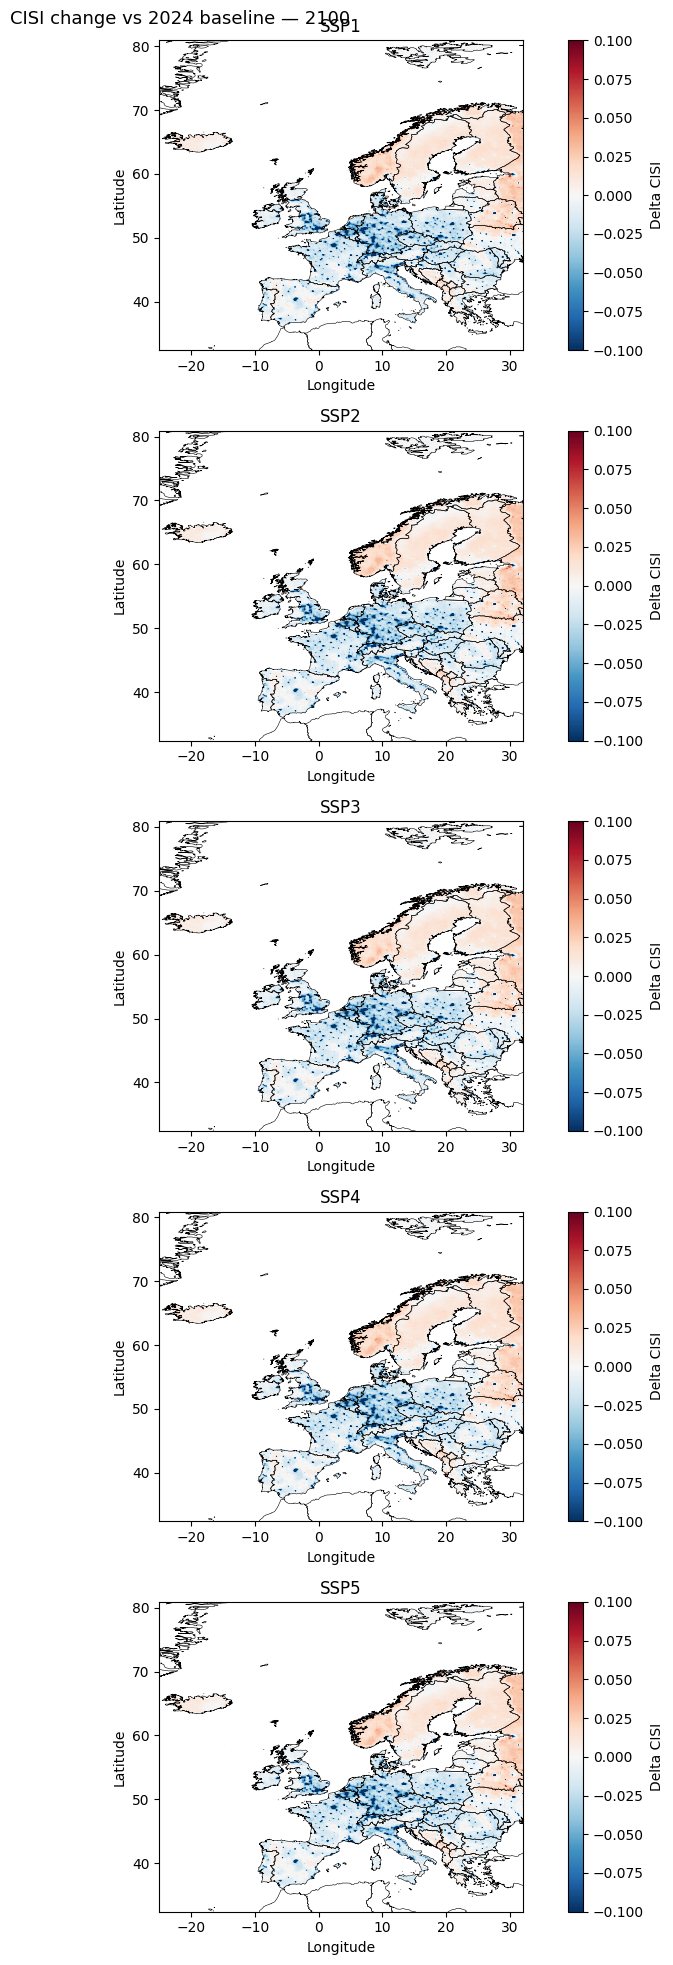

In [9]:
for year in YEARS:
    ssps_ok = [s for s in SSPS if year in results_delta.get(s, {})]
    if not ssps_ok:
        continue

    fig, axes = plt.subplots(len(ssps_ok), 1, figsize=(10, 4 * len(ssps_ok)))
    if len(ssps_ok) == 1:
        axes = [axes]
    fig.suptitle(f"CISI change vs 2024 baseline — {year}", fontsize=13)

    for ax, ssp in zip(axes, ssps_ok):
        delta = results_delta[ssp][year]
        im = ax.imshow(delta, cmap="RdBu_r", vmin=-0.1, vmax=0.1,
                       extent=ext, origin="upper", aspect="auto")
        world.boundary.plot(ax=ax, linewidth=0.4, color="black")
        ax.set_xlim(REF_BOUNDS.left, REF_BOUNDS.right)
        ax.set_ylim(REF_BOUNDS.bottom, REF_BOUNDS.top)
        plt.colorbar(im, ax=ax, label="Delta CISI", fraction=0.03)
        ax.set_title(ssp)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    plt.tight_layout()
    out_fig = f"delta_change_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches="tight")
    print(f"Saved {out_fig}")
    plt.show()


## 10. Summary statistics

In [11]:
print(f"{'SSP':<6} {'Year':>6} {'Mean proj':>12} {'Mean delta':>12} {'Max proj':>10} {'High>0.15 (%)':>14}")
print("-" * 60)
for ssp in SSPS:
    for year in YEARS:
        if year not in results_projected.get(ssp, {}):
            continue
        proj  = results_projected[ssp][year]
        delta = results_delta[ssp][year]
        valid = proj[~np.isnan(proj)]
        high  = (valid > 0.15).mean() * 100
        print(f"{ssp:<6} {year:>6} {valid.mean():>12.4f} {np.nanmean(delta):>+12.4f} {valid.max():>10.4f} {high:>13.1f}%")


SSP      Year    Mean proj   Mean delta   Max proj  High>0.15 (%)
------------------------------------------------------------
SSP1     2030       0.0232      -0.0068     0.5518           0.4%
SSP1     2050       0.0233      -0.0066     0.5489           0.4%
SSP1     2100       0.0234      -0.0066     0.5489           0.4%
SSP2     2030       0.0229      -0.0071     0.5593           0.4%
SSP2     2050       0.0231      -0.0069     0.5535           0.4%
SSP2     2100       0.0233      -0.0066     0.5547           0.4%
SSP3     2030       0.0229      -0.0071     0.5682           0.4%
SSP3     2050       0.0231      -0.0069     0.5563           0.4%
SSP3     2100       0.0232      -0.0067     0.5627           0.4%
SSP4     2030       0.0230      -0.0070     0.5647           0.4%
SSP4     2050       0.0232      -0.0068     0.5526           0.4%
SSP4     2100       0.0233      -0.0067     0.5527           0.4%
SSP5     2030       0.0230      -0.0070     0.5632           0.4%
SSP5     2050  

## 11. Summary statistics plots — all years

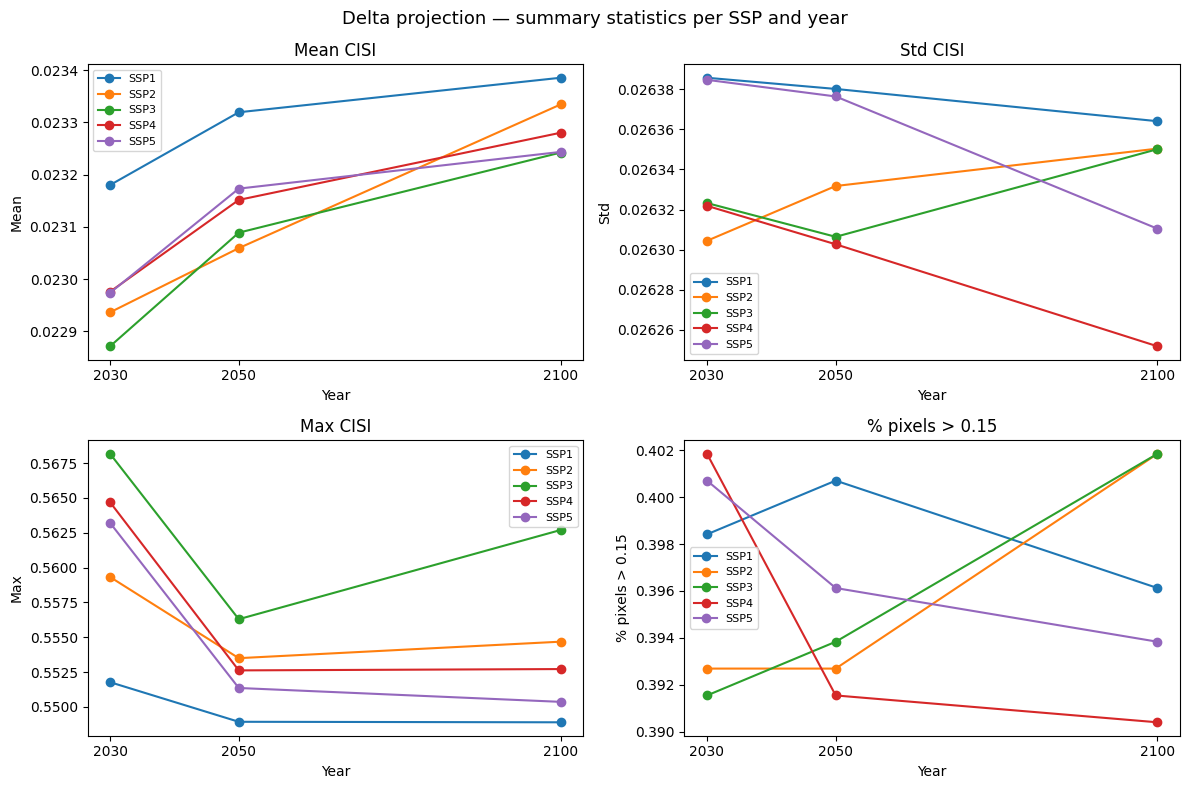

In [12]:
YEARS_ALL = [2030, 2050, 2100]

stats_proj = {ssp: {"mean": [], "std": [], "max": [], "high": []} for ssp in SSPS}
for ssp in SSPS:
    for year in YEARS_ALL:
        if year not in results_projected.get(ssp, {}):
            for m in stats_proj[ssp]: stats_proj[ssp][m].append(np.nan)
            continue
        valid = results_projected[ssp][year][~np.isnan(results_projected[ssp][year])]
        stats_proj[ssp]["mean"].append(valid.mean())
        stats_proj[ssp]["std"].append(valid.std())
        stats_proj[ssp]["max"].append(valid.max())
        stats_proj[ssp]["high"].append((valid > 0.15).mean() * 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Delta projection — summary statistics per SSP and year", fontsize=13)

keys    = ["mean", "std", "max", "high"]
titles  = ["Mean CISI", "Std CISI", "Max CISI", "% pixels > 0.15"]
ylabels = ["Mean", "Std", "Max", "% pixels > 0.15"]

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        ax.plot(YEARS_ALL, stats_proj[ssp][key], marker="o", label=ssp)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS_ALL)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("delta_summary_stats.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. 2024 vs 2030 — observed baseline on x-axis

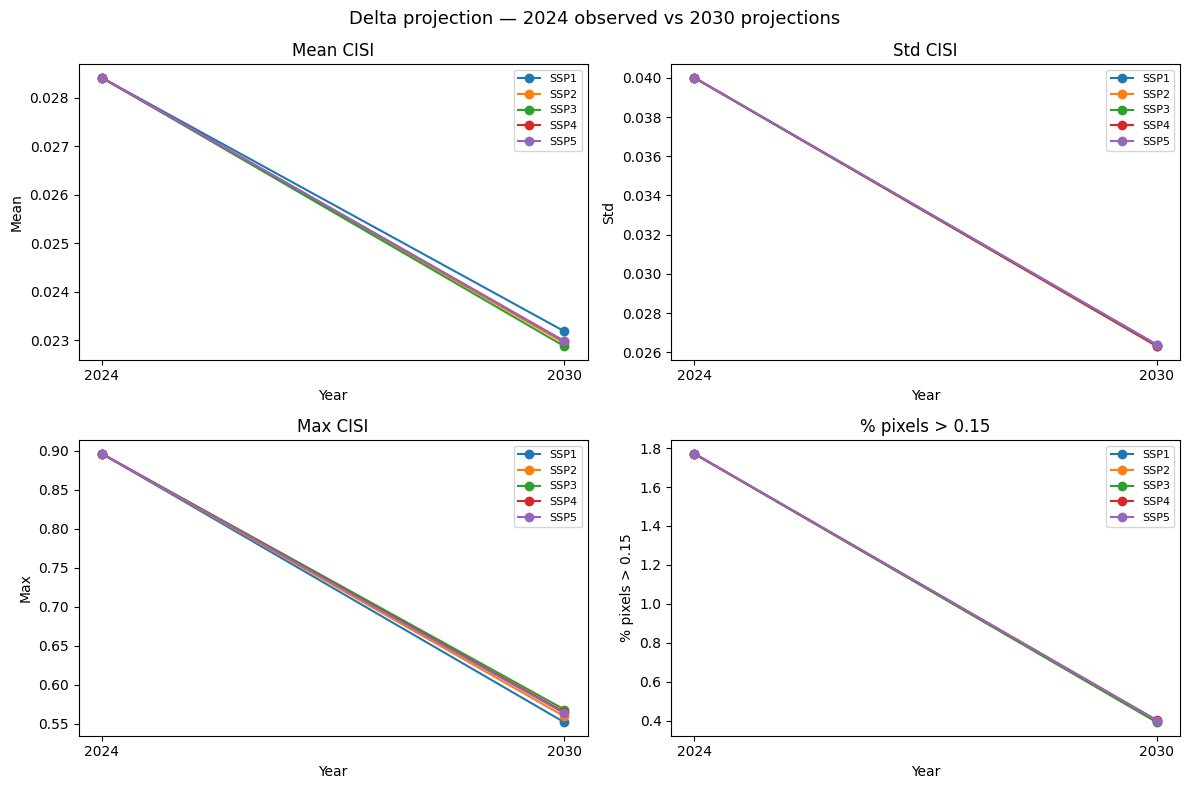

In [13]:
valid_2024 = cisi_2024[~np.isnan(cisi_2024)]
stats_2024 = {
    "mean": valid_2024.mean(),
    "std":  valid_2024.std(),
    "max":  valid_2024.max(),
    "high": (valid_2024 > 0.15).mean() * 100,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Delta projection — 2024 observed vs 2030 projections", fontsize=13)

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        y_2024 = stats_2024[key]
        y_2030 = stats_proj[ssp][key][YEARS_ALL.index(2030)]
        ax.plot([2024, 2030], [y_2024, y_2030], marker="o", label=ssp)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks([2024, 2030])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("delta_stats_2024_2030.png", dpi=150, bbox_inches="tight")
plt.show()